In [1]:
import sys
from pathlib import Path

# Add project root to sys.path
sys.path.insert(0, str(Path('.').resolve().parent))
results_dir = Path("..") / "results"

In [2]:
import scripts.db.db_utils as db_utils
from scripts.plots.plot_trajectory import plot_trajectory_from_id, plot_trajectory_from_ids
import matplotlib.pyplot as plt


In [10]:
TASK = 'ChickenBroth'
TREATMENT = 'Y'
BODYPART = 'Midback'
MAZE_NUMBER = 4
# Query a specific subset
query = """
    SELECT id FROM public.experimental_metadata
    WHERE task = %s
    AND treatment = %s
    AND maze_number = %s
    ORDER BY id
"""
ids = db_utils.fetch_ids_with_params(query, (TASK, TREATMENT, MAZE_NUMBER))
print(len(ids))

12


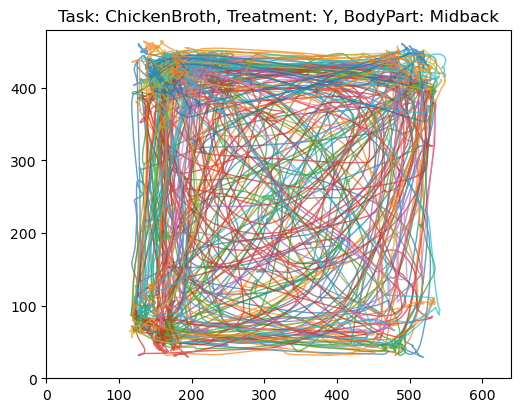

In [11]:
ax = plot_trajectory_from_ids(ids, smoothing_window=11, likelihood_threshold=0.8, show=False)
ax.set_title(f'Task: {TASK}, Treatment: {TREATMENT}, BodyPart: {BODYPART}')

fig = ax.figure
filename = f"{TASK}_{TREATMENT}_{BODYPART}".replace(" ", "_")
ax.figure.savefig(results_dir/ f"{filename}.png", dpi=300, bbox_inches="tight")
plt.show()